# 01 · 방법 1 — 가장 싼 필요 자본 K

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/01_%EB%B0%A9%EB%B2%951_%EA%B0%80%EC%9E%A5%EC%8B%BC%ED%95%84%EC%9A%94%EC%9E%90%EB%B3%B8.ipynb)

**W06 M8 GBI 강의본 23~33장 · 부록 B-1~B-5(129~133장)** 을 손계산 순서 그대로 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 문제 · 가정 | 26 · 27장 | 55세 · 금융자산 10억 · 10년 · 세 목표 |
| ① z값 | 24장 | 95 · 70 · 30% → 1.645 · 0.524 · −0.524 |
| ② 최적 주식 비중 w* | 31 · 32장 | w* = λ/σ² − z/(σ√T), 0~1로 자르기 |
| ③ 확률 조정 성장률 g | 30 · 33장 | g = r + wλ − ½w²σ² − z·wσ/√T |
| ④ 필요 자본 K | 25 · 33장 | K = G·e^(−T·g) → 4.91 · 2.24 · 1.97억 |
| ⑤ 합 · 남는 자금 · 배분 | 28 · 33장 | 9.13억 · 0.87억 · 49 / 22 / 28% |
| 아홉 칸 표 · 잉여 처리 | 27장 · B-2 · B-3 | GHP · 균형형 · 주식 × 세 목표 |

위에서부터 순서대로 실행하면 됩니다. 계산은 가벼워 몇 초 안에 끝납니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 문제와 가정 — 강의 27 · 33장
55세, 금융자산 10억, 10년 뒤 은퇴. 목표 세 개를 **금액 G**와 **달성 확률 p**로 적습니다.

| 목표 | G (10년 뒤, 실질) | p |
|---|---|---|
| Safety | 6억 | 95% |
| Market | 3억 | 70% |
| Aspirational | 5억 | 30% |

자본시장 가정(부록 B-2): GHP 실질 수익 r = 2%(변동성 0), 주식 초과수익 λ = 6%, 주식 변동성 σ = 20%.
GHP와 주식을 비중 w로 섞으면 성장률(로그)은 m = r + wλ − ½w²σ², 변동성은 wσ입니다.

In [2]:
W_TOTAL = 10.0                 # 금융자산(억)
T = 10                         # 남은 연수
r, lam, sig = 0.02, 0.06, 0.20 # GHP 실질 수익 · 주식 초과수익 · 주식 변동성
GOALS = [("Safety", 6.0, 0.95), ("Market", 3.0, 0.70), ("Aspirational", 5.0, 0.30)]
for name, G, p in GOALS:
    print(f"{name:13s} G = {G:.0f}억 · p = {p:.0%}")

Safety        G = 6억 · p = 95%
Market        G = 3억 · p = 70%
Aspirational  G = 5억 · p = 30%


## 2. ① 목표 읽기 — 확률 p를 z값으로 (강의 24장)
"확률 p로 G 이상"은 표준정규의 하위 (1 − p) 지점, 즉 **나쁜 운 −z** 에서도 G에 닿는다는 뜻입니다.
z = Φ⁻¹(p). 강의는 소수 셋째 자리로 반올림한 값(1.645 · 0.524 · −0.524)을 씁니다.

In [3]:
from scipy.stats import norm
Z_EXACT = {p: norm.ppf(p) for _, _, p in GOALS}
Z = {0.95: 1.645, 0.70: 0.524, 0.30: -0.524}       # 강의 손계산 값
for name, G, p in GOALS:
    print(f"{name:13s} p {p:.0%} → z = Φ⁻¹(p) = {Z_EXACT[p]:+.4f} (강의 {Z[p]:+.3f})")
check("z(95%)", Z_EXACT[0.95], 1.645, 0.001, ".3f")
check("z(70%)", Z_EXACT[0.70], 0.524, 0.001, ".3f")
check("z(30%)", Z_EXACT[0.30], -0.524, 0.001, ".3f")

Safety        p 95% → z = Φ⁻¹(p) = +1.6449 (강의 +1.645)
Market        p 70% → z = Φ⁻¹(p) = +0.5244 (강의 +0.524)
Aspirational  p 30% → z = Φ⁻¹(p) = -0.5244 (강의 -0.524)
✓ z(95%): 계산 1.645 · 강의 1.645 (허용 ±0.001)
✓ z(70%): 계산 0.524 · 강의 0.524 (허용 ±0.001)
✓ z(30%): 계산 -0.524 · 강의 -0.524 (허용 ±0.001)


## 3. ② 최적 주식 비중 w* (강의 31 · 32장, 유도는 부록 B-5)
목표 하나의 확률 조정 성장률(× T)은

T·g(w) = T(r + wλ) − ½Tw²σ² − z·wσ√T   (성장 + · 변동성 비용 − · 확률 안전마진 −)

이를 w로 미분해 0으로 놓으면 **w\* = λ/σ² − z/(σ√T)** 이고, 레버리지 · 공매도가 없으니 0~1로 자릅니다.
첫째 항 λ/σ² = 1.5는 확률 조건이 없을 때의 Merton 비중, 둘째 항이 확률 목표에 따른 조정입니다.

In [4]:
sqrtT = math.sqrt(T)
merton = lam / sig**2
print(f"λ/σ² = {merton:.2f} · σ√T = {sig * sqrtT:.3f}")
W_RAW, W_STAR = {}, {}
for name, G, p in GOALS:
    z = Z[p]
    W_RAW[name] = merton - z / (sig * sqrtT)
    W_STAR[name] = min(max(W_RAW[name], 0.0), 1.0)
    print(f"{name:13s} w* = 1.5 − ({z:+.3f}) ÷ {sig*sqrtT:.3f} = {W_RAW[name]:+.2f} → 0~1로 자르면 {W_STAR[name]:.1%}")
check("Safety w* (자르기 전)", W_RAW["Safety"], -1.10, 0.01, ".2f")
check("Market w*", W_RAW["Market"], 0.67, 0.005, ".2f")
check("Aspirational w* (자르기 전)", W_RAW["Aspirational"], 2.33, 0.01, ".2f")

λ/σ² = 1.50 · σ√T = 0.632
Safety        w* = 1.5 − (+1.645) ÷ 0.632 = -1.10 → 0~1로 자르면 0.0%
Market        w* = 1.5 − (+0.524) ÷ 0.632 = +0.67 → 0~1로 자르면 67.1%
Aspirational  w* = 1.5 − (-0.524) ÷ 0.632 = +2.33 → 0~1로 자르면 100.0%
✓ Safety w* (자르기 전): 계산 -1.10 · 강의 -1.10 (허용 ±0.01)
✓ Market w*: 계산 0.67 · 강의 0.67 (허용 ±0.005)
✓ Aspirational w* (자르기 전): 계산 2.33 · 강의 2.33 (허용 ±0.01)


**확인 — 공식이 정말 K를 가장 작게 하나?** 미분 대신 컴퓨터로 w를 0~1에서 직접 훑어 g가 가장 큰 w를 찾아봅니다(= K가 가장 작은 w).

In [5]:
from scipy.optimize import minimize_scalar
def g_of(w, z):
    """확률 조정 성장률 g = r + wλ − ½w²σ² − z·wσ/√T"""
    return r + w * lam - 0.5 * w * w * sig * sig - z * w * sig / sqrtT
for name, G, p in GOALS:
    res = minimize_scalar(lambda w: -g_of(w, Z[p]), bounds=(0, 1), method="bounded")
    print(f"{name:13s} 수치 최적 w = {res.x:.4f} · 공식 w* = {W_STAR[name]:.4f}")
    check(f"{name} 수치 최적 = 공식", res.x, W_STAR[name], 1e-3)

Safety        수치 최적 w = 0.0000 · 공식 w* = 0.0000
✓ Safety 수치 최적 = 공식: 계산 0.0000 · 강의 0.0000 (허용 ±0.001)
Market        수치 최적 w = 0.6715 · 공식 w* = 0.6715
✓ Market 수치 최적 = 공식: 계산 0.6715 · 강의 0.6715 (허용 ±0.001)
Aspirational  수치 최적 w = 1.0000 · 공식 w* = 1.0000
✓ Aspirational 수치 최적 = 공식: 계산 1.0000 · 강의 1.0000 (허용 ±0.001)


## 4. ③ 확률 조정 성장률 g · ④ 필요 자본 K (강의 33장)
K = G × exp(−T·g). 로그를 취하면 **K 최소 = g 최대** — 목표끼리 묶이지 않으니 목표마다 따로 풀면 됩니다.

In [6]:
K1 = {}
print(f"{'목표':13s} {'w*':>7s} {'m':>8s} {'변동성':>8s} {'g':>8s} {'K(억)':>8s}")
for name, G, p in GOALS:
    w, z = W_STAR[name], Z[p]
    m = r + w * lam - 0.5 * w * w * sig * sig
    s = w * sig
    g = m - z * s / sqrtT
    K1[name] = G * math.exp(-T * g)
    print(f"{name:13s} {w:7.1%} {m:8.2%} {s:8.2%} {g:8.2%} {K1[name]:8.3f}")
check("Safety g", g_of(W_STAR['Safety'], Z[0.95]), 0.020, 0.0001, ".4f")
check("Market g", g_of(W_STAR['Market'], Z[0.70]), 0.0290, 0.0001, ".4f")
check("Aspirational g", g_of(W_STAR['Aspirational'], Z[0.30]), 0.0931, 0.0001, ".4f")
check("Safety K (억)", K1["Safety"], 4.91, 0.005, ".2f")
check("Market K (억)", K1["Market"], 2.24, 0.005, ".2f")
check("Aspirational K (억)", K1["Aspirational"], 1.97, 0.005, ".2f")

목표                 w*        m      변동성        g     K(억)
Safety           0.0%    2.00%    0.00%    2.00%    4.912
Market          67.1%    5.13%   13.43%    2.90%    2.244
Aspirational   100.0%    6.00%   20.00%    9.31%    1.970
✓ Safety g: 계산 0.0200 · 강의 0.0200 (허용 ±0.0001)
✓ Market g: 계산 0.0290 · 강의 0.0290 (허용 ±0.0001)
✓ Aspirational g: 계산 0.0931 · 강의 0.0931 (허용 ±0.0001)
✓ Safety K (억): 계산 4.91 · 강의 4.91 (허용 ±0.005)
✓ Market K (억): 계산 2.24 · 강의 2.24 (허용 ±0.005)
✓ Aspirational K (억): 계산 1.97 · 강의 1.97 (허용 ±0.005)


## 5. ⑤ 합 · 남는 자금 · 배분 (강의 28 · 33장)
합 4.91 + 2.24 + 1.97 = 9.13억 ≤ 10억. 남는 0.87억은 Aspirational(꿈의 계좌)로 보냅니다 → 4.91 · 2.24 · 2.84억 = **49 / 22 / 28%**.
49 / 22 / 28은 입력이 아니라 **결과**입니다(26장).

In [7]:
total = sum(K1.values())
spare = W_TOTAL - total
alloc = {"Safety": K1["Safety"], "Market": K1["Market"], "Aspirational": K1["Aspirational"] + spare}
print(f"합 {total:.2f}억 · 남는 자금 {spare:.2f}억")
for k, v in alloc.items():
    print(f"  {k:13s} {v:.2f}억 = {v / W_TOTAL:.1%}")
look_stock = W_STAR["Market"] * K1["Market"] + alloc["Aspirational"]
print(f"합쳐 보면(look-through) 주식 {look_stock:.2f}억({look_stock/W_TOTAL:.1%}) · 채권·GHP {W_TOTAL-look_stock:.2f}억")
check("합계 (억)", total, 9.13, 0.005, ".2f")
check("남는 자금 (억)", spare, 0.87, 0.005, ".2f")
check("Safety 비중 (%)", 100 * alloc["Safety"] / W_TOTAL, 49, 0.5, ".1f")
check("Market 비중 (%)", 100 * alloc["Market"] / W_TOTAL, 22, 0.5, ".1f")
check("Aspirational 비중 (%)", 100 * alloc["Aspirational"] / W_TOTAL, 28, 0.5, ".1f")
check("look-through 주식 (억)", look_stock, 4.35, 0.005, ".2f")

합 9.13억 · 남는 자금 0.87억
  Safety        4.91억 = 49.1%
  Market        2.24억 = 22.4%
  Aspirational  2.84억 = 28.4%
합쳐 보면(look-through) 주식 4.35억(43.5%) · 채권·GHP 5.65억
✓ 합계 (억): 계산 9.13 · 강의 9.13 (허용 ±0.005)
✓ 남는 자금 (억): 계산 0.87 · 강의 0.87 (허용 ±0.005)
✓ Safety 비중 (%): 계산 49.1 · 강의 49.0 (허용 ±0.5)
✓ Market 비중 (%): 계산 22.4 · 강의 22.0 (허용 ±0.5)
✓ Aspirational 비중 (%): 계산 28.4 · 강의 28.0 (허용 ±0.5)
✓ look-through 주식 (억): 계산 4.35 · 강의 4.35 (허용 ±0.005)


## 6. 남는 자금의 쓰임과 부족할 때 (강의 28장 · 부록 B-3 131장)
- (a) 확률 30%를 유지하고 목표를 올리면 5억 → **7.22억**
- (b) 목표 5억을 유지하고 확률을 올리면 30% → **약 52%**
- 자산이 8억이라면 Safety · Market을 먼저 사고 남는 자금으로 상속 목표 **약 2.1억**(30%)

In [8]:
KA_plus = alloc["Aspirational"]                          # 1.97 + 0.87 = 2.84억, 주식 100%
gA = g_of(1.0, Z[0.30])
G_up = KA_plus * math.exp(T * gA)                        # (a) 같은 확률 30%로 살 수 있는 목표
mA, sA = r + lam - 0.5 * sig**2, sig                     # 주식 100% 계좌의 로그 성장률 · 변동성
p_up = 1 - norm.cdf((math.log(5.0 / KA_plus) - T * mA) / (sA * sqrtT))   # (b) 목표 5억의 확률
left8 = 8.0 - K1["Safety"] - K1["Market"]
G8 = left8 * math.exp(T * gA)
print(f"(a) 목표 상향: {G_up:.2f}억 · (b) 확률 상향: {p_up:.1%} · 자산 8억: 남는 {left8:.2f}억 → 상속 목표 {G8:.2f}억")
check("(a) 목표 상향 (억)", G_up, 7.22, 0.01, ".2f")
check("(b) 확률 상향 (%)", 100 * p_up, 52, 1.0, ".1f")
check("자산 8억일 때 상속 목표 (억)", G8, 2.1, 0.06, ".2f")

(a) 목표 상향: 7.22억 · (b) 확률 상향: 52.2% · 자산 8억: 남는 0.84억 → 상속 목표 2.14억
✓ (a) 목표 상향 (억): 계산 7.22 · 강의 7.22 (허용 ±0.01)
✓ (b) 확률 상향 (%): 계산 52.2 · 강의 52.0 (허용 ±1)
✓ 자산 8억일 때 상속 목표 (억): 계산 2.14 · 강의 2.10 (허용 ±0.06)


## 7. 아홉 칸 표 — 목표 × 포트폴리오 (강의 27장 · 부록 B-2 130장)
w를 고르지 않고 이미 정해진 상품 셋(GHP · 균형형 · 주식) 중에서 고르면 어떻게 되나?
지수 = −mT + zσ√T, K = G × exp(지수). 균형형은 m 4.5% · σ 9%, 주식은 m 6% · σ 20%, GHP는 m 2% · σ 0.

In [9]:
PORTS = {"GHP": (0.02, 0.0), "균형형": (0.045, 0.09), "주식": (0.06, 0.20)}
LECT9 = {"Safety": [4.91, 6.11, 9.32], "Market": [2.46, 2.22, 2.29], "Aspirational": [4.09, 2.75, 1.97]}
K9 = {}
print(f"{'목표':13s}" + "".join(f"{k:>10s}" for k in PORTS))
for name, G, p in GOALS:
    row = [G * math.exp(-m * T + Z[p] * s * sqrtT) for m, s in PORTS.values()]
    K9[name] = row
    best = int(np.argmin(row))
    print(f"{name:13s}" + "".join(f"{v:9.2f}{'*' if i == best else ' '}" for i, v in enumerate(row)))
print("* = 그 목표에서 가장 싼 포트폴리오")
for name, *_ in GOALS:
    for i, port in enumerate(PORTS):
        check(f"아홉 칸 {name}·{port}", K9[name][i], LECT9[name][i], 0.006, ".2f")
# 부록 B-1 검산: Safety를 균형형에 넣으면 6 × exp(−0.45 + 1.645 × 0.285) = 6.11억
check("B-1 검산 Safety·균형형", 6 * math.exp(-0.45 + 1.645 * 0.09 * sqrtT), 6.11, 0.006, ".2f")

목표                  GHP       균형형        주식
Safety            4.91*     6.11      9.32 
Market            2.46      2.22*     2.29 
Aspirational      4.09      2.75      1.97*
* = 그 목표에서 가장 싼 포트폴리오
✓ 아홉 칸 Safety·GHP: 계산 4.91 · 강의 4.91 (허용 ±0.006)
✓ 아홉 칸 Safety·균형형: 계산 6.11 · 강의 6.11 (허용 ±0.006)
✓ 아홉 칸 Safety·주식: 계산 9.32 · 강의 9.32 (허용 ±0.006)
✓ 아홉 칸 Market·GHP: 계산 2.46 · 강의 2.46 (허용 ±0.006)
✓ 아홉 칸 Market·균형형: 계산 2.22 · 강의 2.22 (허용 ±0.006)
✓ 아홉 칸 Market·주식: 계산 2.29 · 강의 2.29 (허용 ±0.006)
✓ 아홉 칸 Aspirational·GHP: 계산 4.09 · 강의 4.09 (허용 ±0.006)
✓ 아홉 칸 Aspirational·균형형: 계산 2.75 · 강의 2.75 (허용 ±0.006)
✓ 아홉 칸 Aspirational·주식: 계산 1.97 · 강의 1.97 (허용 ±0.006)
✓ B-1 검산 Safety·균형형: 계산 6.11 · 강의 6.11 (허용 ±0.006)


**읽는 법** — 확률이 높은 목표(95%)는 GHP가, 낮은 목표(30%)는 주식이 가장 쌉니다. 70%에서는 아홉 칸 중 균형형(2.22억)이 가장 싸지만,
본문 Market은 GHP + 주식 67% 혼합(2.24억)입니다. "같은 성장률 4.5%에 변동성 9%인 균형형을 쓰면 2.22억 — 변동성이 낮은 상품이 같은 목표를 더 싸게 산다"(33장 각주).

## 8. 그래프 ① — 달성 확률 p와 최적 주식 비중 w* (강의 31 · 32장 계열)
확률 목표가 높을수록 주식 비중은 0으로, 낮을수록 100%로 갑니다.

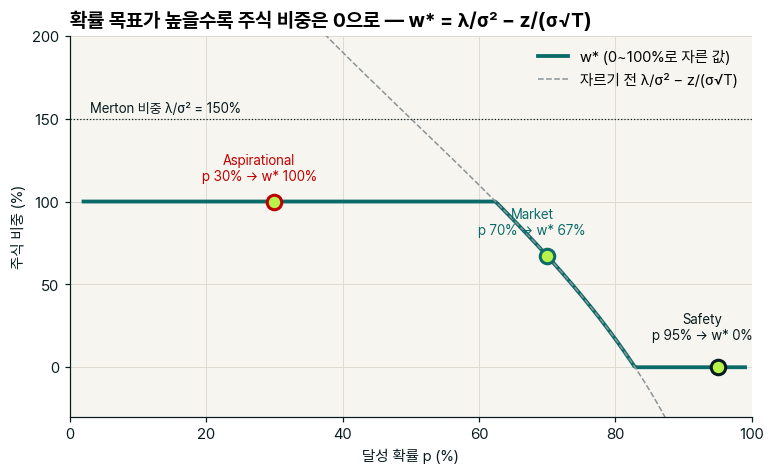

In [10]:
ps = np.linspace(0.02, 0.99, 300)
w_raw = merton - norm.ppf(ps) / (sig * sqrtT)
fig, ax = plt.subplots()
ax.plot(ps * 100, np.clip(w_raw, 0, 1) * 100, color=TEAL, lw=2.5, label="w* (0~100%로 자른 값)")
ax.plot(ps * 100, w_raw * 100, color=GRAY, lw=1, ls="--", label="자르기 전 λ/σ² − z/(σ√T)")
ax.axhline(merton * 100, color=INK, lw=0.8, ls=":")
ax.text(3, merton * 100 + 4, "Merton 비중 λ/σ² = 150%", color=INK, fontsize=9)
for (name, G, p), c in zip(GOALS, [INK, TEAL, RED]):
    ax.scatter(p * 100, W_STAR[name] * 100, s=90, color=LIME, edgecolor=c, zorder=5, lw=2)
    ax.annotate(f"{name}\np {p:.0%} → w* {W_STAR[name]:.0%}", (p * 100, W_STAR[name] * 100),
                textcoords="offset points", xytext=(-10, 14 if name != "Safety" else 18), fontsize=9, color=c, ha="center")
ax.set_ylim(-30, 200); ax.set_xlim(0, 100)
ax.set_xlabel("달성 확률 p (%)"); ax.set_ylabel("주식 비중 (%)")
ax.set_title("확률 목표가 높을수록 주식 비중은 0으로 — w* = λ/σ² − z/(σ√T)")
ax.legend(loc="upper right")
plt.show()

## 9. 그래프 ② — 주식 비중 w에 따른 필요 자본 K (최솟값 표시)
목표마다 K(w) = G × exp(−T·g(w)) 곡선을 그리고, 가장 낮은 점(= w\*)에 표시합니다. Safety는 w = 0, Aspirational은 w = 1이 끝점 최솟값입니다.

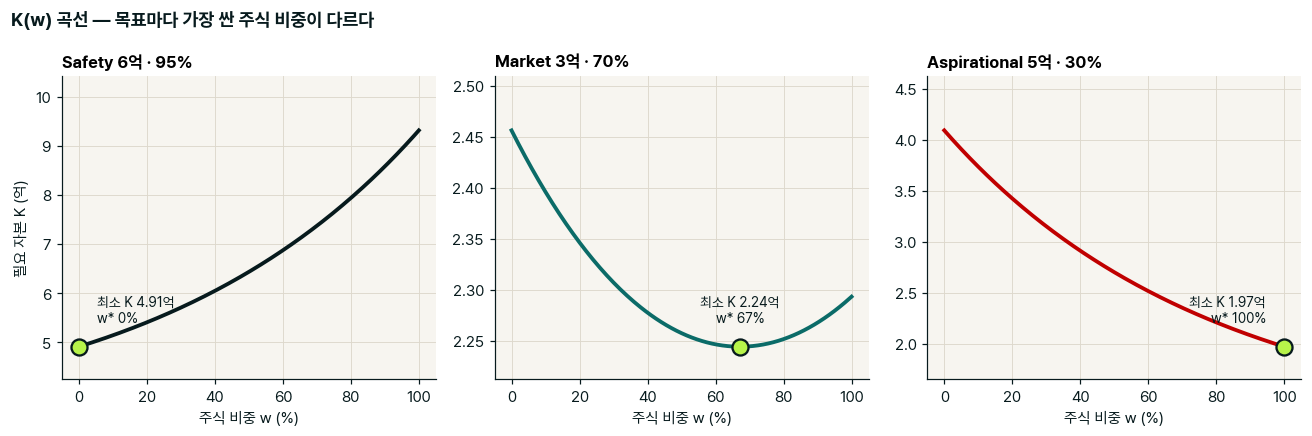

In [11]:
ws = np.linspace(0, 1, 201)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, (name, G, p), c in zip(axes, GOALS, [INK, TEAL, RED]):
    Kw = G * np.exp(-T * g_of(ws, Z[p]))
    ax.plot(ws * 100, Kw, color=c, lw=2.5)
    ax.scatter(W_STAR[name] * 100, K1[name], s=110, color=LIME, edgecolor=INK, zorder=5, lw=1.5)
    ha, dx = ("left", 12) if W_STAR[name] < 0.05 else (("right", -12) if W_STAR[name] > 0.95 else ("center", 0))
    ax.annotate(f"최소 K {K1[name]:.2f}억\nw* {W_STAR[name]:.0%}", (W_STAR[name] * 100, K1[name]),
                textcoords="offset points", xytext=(dx, 16), ha=ha, fontsize=9, color=INK)
    ax.set_title(f"{name} {G:.0f}억 · {p:.0%}", fontsize=11)
    ax.set_xlabel("주식 비중 w (%)")
    lo, hi = Kw.min(), Kw.max()
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.25 * (hi - lo))
axes[0].set_ylabel("필요 자본 K (억)")
fig.suptitle("K(w) 곡선 — 목표마다 가장 싼 주식 비중이 다르다", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(); plt.show()

## 10. 그래프 ③ — 세 목표 막대와 10억의 배분
왼쪽: 목표마다 세 포트폴리오(GHP · 균형형 · 주식)와 공식 혼합(w\*)의 필요 자본. 오른쪽: 공식 비중으로 산 결과 10억의 배분(49 / 22 / 28%).

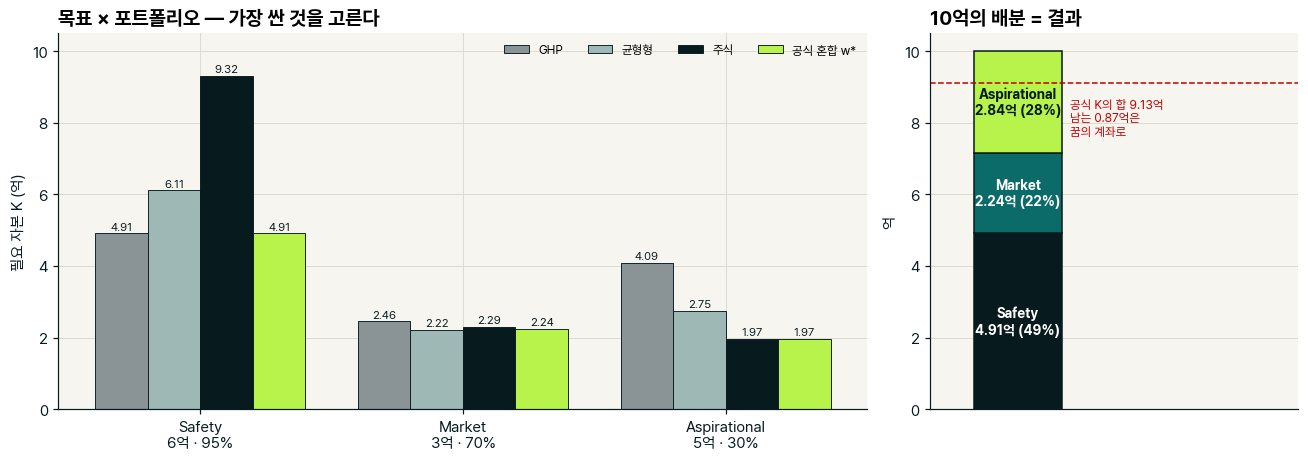

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [2.2, 1]})
names = [g[0] for g in GOALS]
x = np.arange(3); bw = 0.2
cols = [GRAY, "#9DB8B5", INK, LIME]
labels = list(PORTS) + ["공식 혼합 w*"]
for j in range(4):
    vals = [K9[n][j] if j < 3 else K1[n] for n in names]
    bars = ax1.bar(x + (j - 1.5) * bw, vals, bw, color=cols[j], edgecolor=INK, lw=0.6, label=labels[j])
    for b, v in zip(bars, vals):
        ax1.text(b.get_x() + bw / 2, v + 0.1, f"{v:.2f}", ha="center", fontsize=7.5, color=INK)
ax1.set_xticks(x, [f"{n}\n{G:.0f}억 · {p:.0%}" for n, G, p in GOALS])
ax1.set_ylabel("필요 자본 K (억)"); ax1.legend(ncol=4, fontsize=8, loc="upper right")
ax1.set_title("목표 × 포트폴리오 — 가장 싼 것을 고른다"); ax1.set_ylim(0, 10.5)
bottom = 0
for (k, v), c in zip(alloc.items(), [INK, TEAL, LIME]):
    ax2.bar(0, v, 0.5, bottom=bottom, color=c, edgecolor=INK)
    ax2.text(0, bottom + v / 2, f"{k}\n{v:.2f}억 ({v / W_TOTAL:.0%})", ha="center", va="center",
             color="white" if c != LIME else INK, fontsize=9, fontweight="bold")
    bottom += v
ax2.axhline(K1["Safety"] + K1["Market"] + K1["Aspirational"], color=RED, ls="--", lw=1)
ax2.text(0.3, total - 0.45, f"공식 K의 합 {total:.2f}억\n남는 {spare:.2f}억은\n꿈의 계좌로", color=RED, fontsize=8, ha="left", va="top")
ax2.set_xlim(-0.5, 1.6); ax2.set_xticks([]); ax2.set_ylim(0, 10.5); ax2.set_ylabel("억")
ax2.set_title("10억의 배분 = 결과")
fig.tight_layout(); plt.show()

## 11. 정리
- 입력은 개인(G · T · p · 우선순위)과 운용사의 자본시장 가정(r · λ · σ), 출력은 계산(K와 배분) — 26장의 분업.
- 방법 1은 로그정규 · 고정 비중(연속 재조정)을 가정한 닫힌 해입니다. 두꺼운 꼬리 · 현금흐름 · 동적 규칙은 **04~06 노트북의 몬테카를로(방법 3)** 로 같은 문제를 다시 풉니다.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 34 / 34 통과


---
## 바꿔 보기 (연습 문제)

1. Market의 확률을 70% → 80%로 올리면 w\*와 K는? (힌트: `Z[0.80] = norm.ppf(0.80)`을 추가하고 3~4절 셀을 다시 실행)
2. 주식 변동성 σ를 20% → 25%로 바꾸면 세 목표의 w\*와 합계 K는 어떻게 바뀌나? 남는 자금은 여전히 양수인가?
3. 은퇴까지 T = 10년 → 15년이면? Safety(GHP)와 Aspirational(주식) 중 어느 쪽 K가 더 많이 줄어드는가?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기